In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


In [2]:

CLASS_MAP = {
    "A": 1,
    "B": 1,
    "F": 1,
    "L": 1,
    "N": 0,
    "R": 1,
    "V": 1,
    "f": 1
}

In [3]:
def list_csv_files(root_dir):
    files = []
    for root, _, filenames in os.walk(root_dir):
        for f in filenames:
            if f.endswith(".csv"):
                files.append(os.path.join(root, f))
    return files


In [4]:
class ECGDataset(Dataset):
    def __init__(self, files, class_map, max_len=600):
        self.files = files
        self.class_map = class_map
        self.max_len = max_len
        self.labels = []

        for f in self.files:
            cls = os.path.basename(os.path.dirname(f))
            self.labels.append(self.class_map[cls])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        signal = pd.read_csv(self.files[idx]).iloc[:, 0].values
        signal = signal.astype(np.float32)

        # Padding / corte (ESSENCIAL)
        if len(signal) < self.max_len:
            signal = np.pad(signal, (0, self.max_len - len(signal)))
        else:
            signal = signal[:self.max_len]

        signal = torch.tensor(signal).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        return signal, label


In [5]:
class ECGCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Linear(64, 1)

    def forward(self, x):
        x = self.features(x)
        x = x.squeeze(-1)
        return self.classifier(x)


In [7]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=5):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x).squeeze()
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x).squeeze()
                loss = criterion(logits, y)
                val_loss += loss.item()

                preds = (torch.sigmoid(logits) > 0.5).int()
                correct += (preds == y.int()).sum().item()
                total += y.size(0)

        val_losses.append(val_loss / len(val_loader))
        acc = correct / total

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_losses[-1]:.4f} | "
              f"Val Loss: {val_losses[-1]:.4f} | "
              f"Val Acc: {acc:.4f}")

    return train_losses, val_losses


In [8]:
def evaluate_with_confusion_matrix(model, dataloader, device, threshold=0.5):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x).squeeze()
            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).long()

            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Matriz de confusão
    cm = confusion_matrix(y_true, y_pred)

    print("Classification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Arritmia"]
    ))

    return cm


In [9]:
def plot_confusion_matrix(cm):
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Normal", "Arritmia"],
        yticklabels=["Normal", "Arritmia"]
    )
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão")
    plt.tight_layout()
    plt.show()


Device: cuda
Epoch 1/10 | Train Loss: 0.1795 | Val Loss: 0.1622 | Val Acc: 0.7983
Epoch 2/10 | Train Loss: 0.1448 | Val Loss: 0.1241 | Val Acc: 0.8999
Epoch 3/10 | Train Loss: 0.1088 | Val Loss: 0.1086 | Val Acc: 0.9546
Epoch 4/10 | Train Loss: 0.0890 | Val Loss: 0.0817 | Val Acc: 0.9471
Epoch 5/10 | Train Loss: 0.0740 | Val Loss: 0.0736 | Val Acc: 0.9324
Epoch 6/10 | Train Loss: 0.0652 | Val Loss: 0.0651 | Val Acc: 0.9407
Epoch 7/10 | Train Loss: 0.0601 | Val Loss: 0.0593 | Val Acc: 0.9463
Epoch 8/10 | Train Loss: 0.0562 | Val Loss: 0.0697 | Val Acc: 0.9693
Epoch 9/10 | Train Loss: 0.0529 | Val Loss: 0.0622 | Val Acc: 0.9671
Epoch 10/10 | Train Loss: 0.0526 | Val Loss: 0.0558 | Val Acc: 0.9571


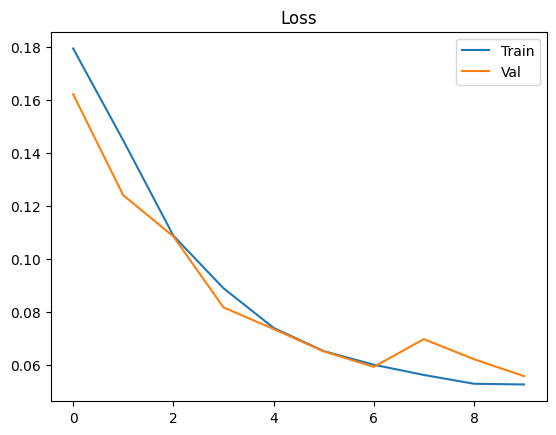

In [10]:
if __name__ == "__main__":


    CLASS_MAP = {
        "A": 1,
        "B": 1,
        "F": 1,
        "L": 1,
        "N": 0,
        "R": 1,
        "V": 1,
        "f": 1
    }

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    train_files = list_csv_files("dataset_split_2/train")
    val_files   = list_csv_files("dataset_split_2/val")

    train_dataset = ECGDataset(train_files, CLASS_MAP)
    val_dataset   = ECGDataset(val_files, CLASS_MAP)

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)

    model = ECGCNN().to(device)

    # Class weight (opcional, mas recomendado)
    num_pos = sum(train_dataset.labels)
    num_neg = len(train_dataset.labels) - num_pos
    pos_weight = torch.tensor([num_neg / num_pos]).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_losses, val_losses = train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=10
    )

    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Val")
    plt.legend()
    plt.title("Loss")
    plt.show()


Classification Report:
              precision    recall  f1-score   support

      Normal       0.84      0.94      0.89      1499
    Arritmia       0.99      0.96      0.97      6944

    accuracy                           0.96      8443
   macro avg       0.91      0.95      0.93      8443
weighted avg       0.96      0.96      0.96      8443



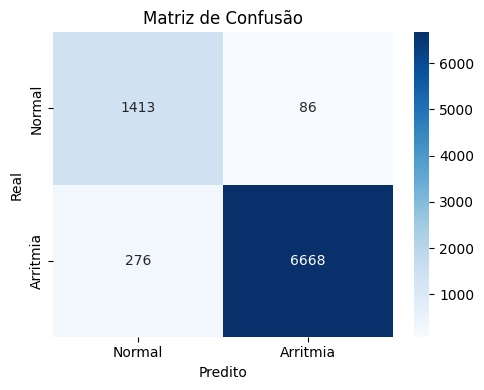

In [11]:
cm = evaluate_with_confusion_matrix(
    model,
    val_loader,
    device,
    threshold=0.5
)

plot_confusion_matrix(cm)


In [12]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
import numpy as np
import torch

def evaluate_with_dynamic_threshold(model, loader, device, plot_roc=True):
    model.eval()
    
    y_true = []
    y_probs = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x).view(-1)
            probs = torch.sigmoid(logits)

            y_true.extend(y.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_probs = np.array(y_probs)

    # =========================
    # 1️⃣ ROC Curve
    # =========================
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    auc = roc_auc_score(y_true, y_probs)

    # =========================
    # 2️⃣ Melhor Threshold (Youden Index)
    # =========================
    youden_index = tpr - fpr
    best_index = np.argmax(youden_index)
    best_threshold = thresholds[best_index]

    print(f"\nMelhor Threshold (Youden): {best_threshold:.4f}")
    print(f"AUC: {auc:.4f}")

    # =========================
    # 3️⃣ Predições com threshold ótimo
    # =========================
    y_pred = (y_probs >= best_threshold).astype(int)

    # =========================
    # 4️⃣ Matriz de Confusão
    # =========================
    cm = confusion_matrix(y_true, y_pred)
    print("\nMatriz de Confusão:")
    print(cm)

    print("\nRelatório de Classificação:")
    print(classification_report(y_true, y_pred, digits=4))

    # =========================
    # 5️⃣ Plot ROC
    # =========================
    if plot_roc:
        import matplotlib.pyplot as plt

        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.scatter(fpr[best_index], tpr[best_index], marker="o")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend()
        plt.show()

    return best_threshold, auc, cm



Melhor Threshold (Youden): 0.3761
AUC: 0.9821

Matriz de Confusão:
[[1396  103]
 [ 185 6759]]

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0     0.8830    0.9313    0.9065      1499
         1.0     0.9850    0.9734    0.9791      6944

    accuracy                         0.9659      8443
   macro avg     0.9340    0.9523    0.9428      8443
weighted avg     0.9669    0.9659    0.9662      8443



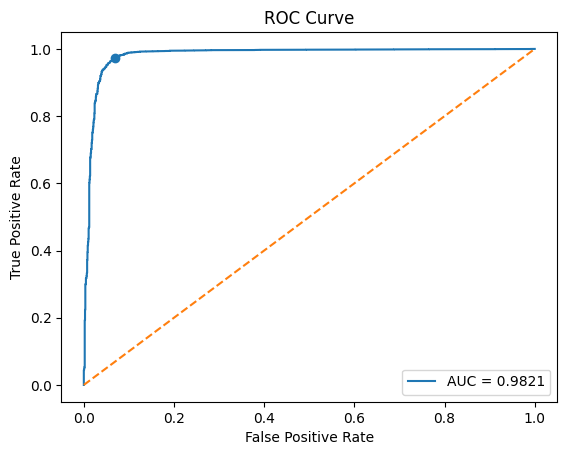

In [13]:
best_threshold, auc, cm = evaluate_with_dynamic_threshold(
    model,
    val_loader,
    device
)
